Detected faces: 12


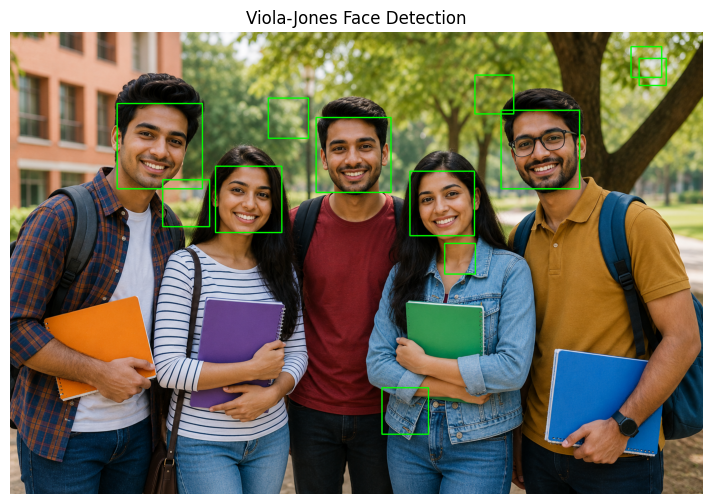

TP: 0 FP: 12 FN: 5
Precision: 0.0
Recall: 0.0
F1-Score: 0


In [11]:
#1. Computing Precision, Recall, and F1-Score for a Viola-Jones Face Detector Output
import cv2, matplotlib.pyplot as plt
import urllib.request

img = cv2.imread("/content/ChatGPT Image Aug 10, 2026, 07_05_01 PM.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
urllib.request.urlretrieve(url, "/content/face.xml")

face = cv2.CascadeClassifier("/content/face.xml")
faces = face.detectMultiScale(gray, 1.1, 5)

print("Detected faces:", len(faces))

for x,y,w,h in faces:
    cv2.rectangle(img,(x,y),(x+w,y+h),(0,255,0),2)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title("Viola-Jones Face Detection")
plt.axis("off")
plt.show()
# Ground-truth boxes: [x,y,w,h]
gt = [(160,100,270,340),(390,250,270,300),
      (680,145,220,280),(850,250,280,300),
      (1090,120,300,330)]

def iou(a,b):
    x1=max(a[0],b[0]); y1=max(a[1],b[1])
    x2=min(a[0]+a[2],b[0]+b[2])
    y2=min(a[1]+a[3],b[1]+b[3])
    inter=max(0,x2-x1)*max(0,y2-y1)
    return inter/(a[2]*a[3]+b[2]*b[3]-inter)

tp=sum(any(iou(g,p)>=0.5 for p in faces) for g in gt)
fp=max(0,len(faces)-tp)
fn=max(0,len(gt)-tp)

p=tp/(tp+fp) if tp+fp else 0
r=tp/(tp+fn) if tp+fn else 0
f1=2*p*r/(p+r) if p+r else 0

print("TP:",tp,"FP:",fp,"FN:",fn)
print("Precision:",round(p,2))
print("Recall:",round(r,2))
print("F1-Score:",round(f1,2))


0: 448x640 5 persons, 1 book, 311.4ms
Speed: 9.8ms preprocess, 311.4ms inference, 6.9ms postprocess per image at shape (1, 3, 448, 640)


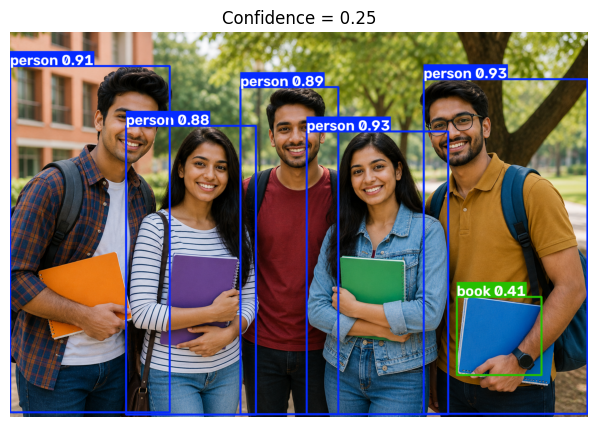

Confidence: 0.25
Detections after NMS: 6
Class: 0 Score: 0.93
Class: 0 Score: 0.93
Class: 0 Score: 0.91
Class: 0 Score: 0.89
Class: 0 Score: 0.88
Class: 73 Score: 0.41

0: 448x640 5 persons, 233.9ms
Speed: 8.3ms preprocess, 233.9ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)


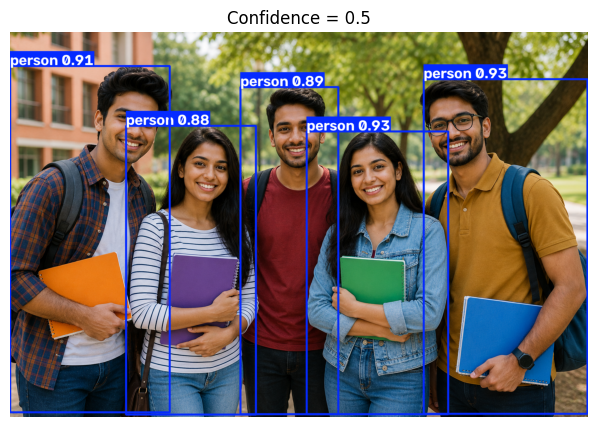

Confidence: 0.5
Detections after NMS: 5
Class: 0 Score: 0.93
Class: 0 Score: 0.93
Class: 0 Score: 0.91
Class: 0 Score: 0.89
Class: 0 Score: 0.88

0: 448x640 5 persons, 253.7ms
Speed: 4.5ms preprocess, 253.7ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)


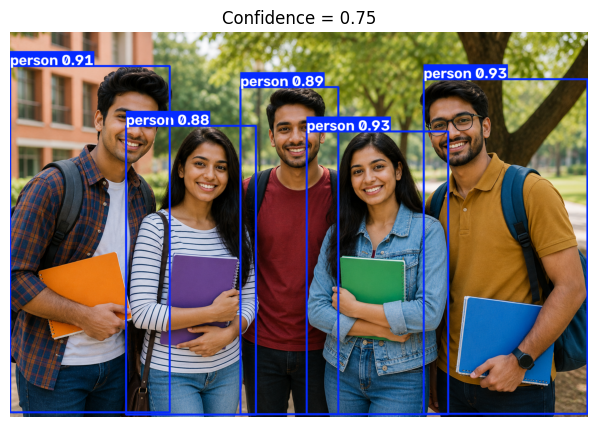

Confidence: 0.75
Detections after NMS: 5
Class: 0 Score: 0.93
Class: 0 Score: 0.93
Class: 0 Score: 0.91
Class: 0 Score: 0.89
Class: 0 Score: 0.88
Observation: Increasing confidence removes low-confidence detections. NMS removes overlapping duplicate boxes.


In [12]:
#2. Interpreting YOLO Bounding Box Confidence Scores and Non-Max Suppression Effects
!pip -q install ultralytics

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/ChatGPT Image Aug 10, 2026, 07_05_01 PM.png")
model = YOLO("yolo11n.pt")

for conf in [0.25, 0.5, 0.75]:

    result = model(img, conf=conf)[0]

    plt.figure(figsize=(8,5))
    plt.imshow(cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB))
    plt.title(f"Confidence = {conf}")
    plt.axis("off")
    plt.show()

    print("Confidence:", conf)
    print("Detections after NMS:", len(result.boxes))

    for box in result.boxes:
        print("Class:", int(box.cls[0]),
              "Score:", round(float(box.conf[0]),2))

print("Observation: Increasing confidence removes low-confidence detections. NMS removes overlapping duplicate boxes.")


0: 448x640 5 persons, 1 book, 152.7ms
Speed: 4.4ms preprocess, 152.7ms inference, 1.1ms postprocess per image at shape (1, 3, 448, 640)


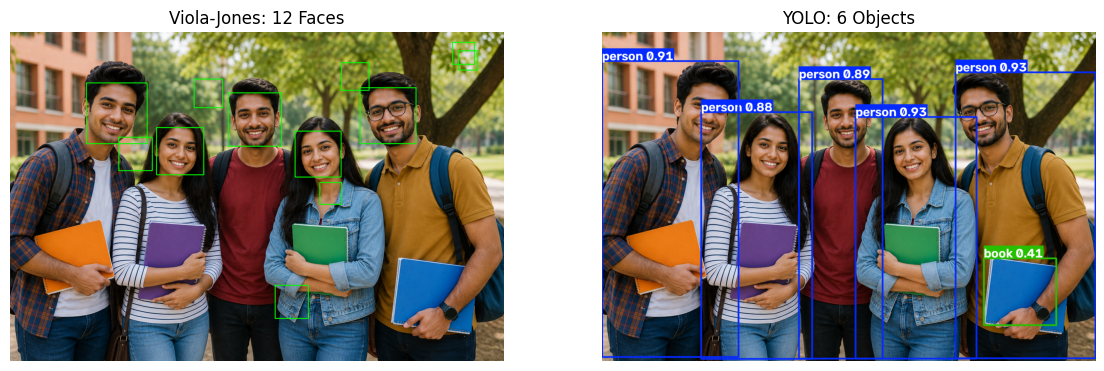

Viola-Jones time: 2433.06 ms
YOLO time: 186.95 ms

Observation: Viola-Jones is lightweight and specialized for faces, while YOLO is a deep-learning detector capable of detecting multiple object classes.


In [13]:
#3. Comparing Detection Accuracy of Viola-Jones vs a Deep-Learning-Based Detector
!pip -q install ultralytics

import cv2, time
import matplotlib.pyplot as plt
from ultralytics import YOLO

img = cv2.imread("/content/ChatGPT Image Aug 10, 2026, 07_05_01 PM.png")

# Viola-Jones
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
face = cv2.CascadeClassifier(
    " /content/face.xml".strip()
)

t = time.time()
faces = face.detectMultiScale(gray,1.1,5)
vtime = time.time()-t

vout = img.copy()
for x,y,w,h in faces:
    cv2.rectangle(vout,(x,y),(x+w,y+h),(0,255,0),2)

# YOLO
model = YOLO("yolo11n.pt")

t = time.time()
result = model(img,conf=0.25)[0]
ytime = time.time()-t

yout = result.plot()

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(vout,cv2.COLOR_BGR2RGB))
plt.title(f"Viola-Jones: {len(faces)} Faces")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(yout,cv2.COLOR_BGR2RGB))
plt.title(f"YOLO: {len(result.boxes)} Objects")
plt.axis("off")

plt.show()

print("Viola-Jones time:",round(vtime*1000,2),"ms")
print("YOLO time:",round(ytime*1000,2),"ms")

print("\nObservation: Viola-Jones is lightweight and specialized for faces, while YOLO is a deep-learning detector capable of detecting multiple object classes.")

Ground Truth: [150, 100, 400, 450]
Prediction: [180, 130, 420, 470]
IoU: 0.713


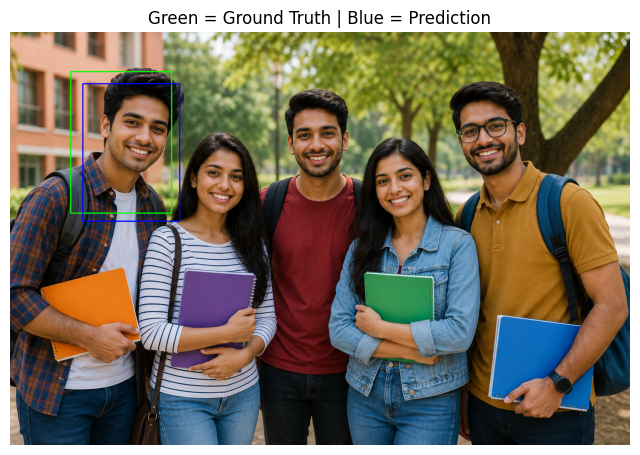

Observation: IoU closer to 1 indicates better overlap between the predicted and ground-truth boxes.


In [14]:
#4. Computing Intersection-over-Union (IoU) for Predicted vs Ground-Truth Bounding Boxes
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/ChatGPT Image Aug 10, 2026, 07_05_01 PM.png")

# [x1, y1, x2, y2]
gt = [150, 100, 400, 450]
pred = [180, 130, 420, 470]

# Intersection
x1 = max(gt[0], pred[0])
y1 = max(gt[1], pred[1])
x2 = min(gt[2], pred[2])
y2 = min(gt[3], pred[3])

intersection = max(0,x2-x1) * max(0,y2-y1)

# Areas
area_gt = (gt[2]-gt[0]) * (gt[3]-gt[1])
area_pred = (pred[2]-pred[0]) * (pred[3]-pred[1])

# IoU
iou = intersection / (area_gt + area_pred - intersection)

print("Ground Truth:", gt)
print("Prediction:", pred)
print("IoU:", round(iou,3))

# Display boxes
cv2.rectangle(img,(gt[0],gt[1]),(gt[2],gt[3]),(0,255,0),2)
cv2.rectangle(img,(pred[0],pred[1]),(pred[2],pred[3]),(255,0,0),2)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title("Green = Ground Truth | Blue = Prediction")
plt.axis("off")
plt.show()

print("Observation: IoU closer to 1 indicates better overlap between the predicted and ground-truth boxes.")

In [ ]:
#5. Analyzing Optical Flow Vectors Computed via the Lucas-Kanade Method
import cv2
from google.colab.patches import cv2_imshow

video = "/content/sample-10s.mp4"
cap = cv2.VideoCapture(video)

ret, old = cap.read()
old_gray = cv2.cvtColor(old,cv2.COLOR_BGR2GRAY)

points = cv2.goodFeaturesToTrack(old_gray,100,0.3,7)

for i in range(50):
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)

    new, status, _ = cv2.calcOpticalFlowPyrLK(
        old_gray,gray,points,None
    )

    for p1,p2,s in zip(points,new,status):
        if s:
            x1,y1 = p1.ravel().astype(int)
            x2,y2 = p2.ravel().astype(int)
            cv2.arrowedLine(
                frame,(x1,y1),(x2,y2),(0,255,0),2
            )

    if i % 10 == 0:
        cv2_imshow(frame)

    old_gray = gray
    points = new.reshape(-1,1,2)

cap.release()

print("Lucas-Kanade optical flow completed.")
print("Observation: Arrows show the motion of selected feature points between frames.")

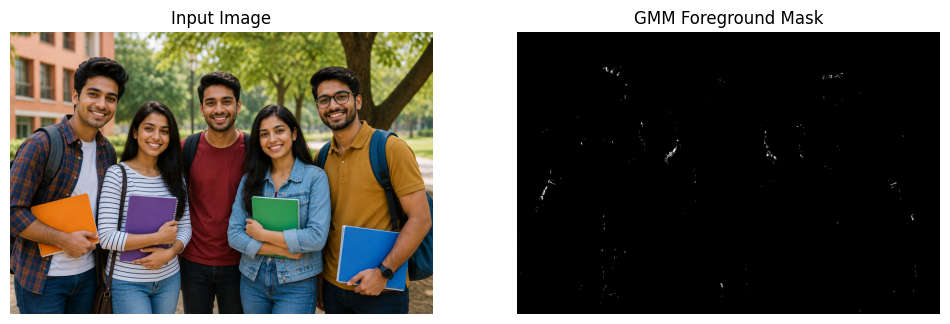

Observation: GMM separates pixels that differ from the estimated background.


In [16]:
#6. Interpreting a Gaussian Mixture Model for Background-Foreground Segmentation
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/ChatGPT Image Aug 10, 2026, 07_05_01 PM.png")

# GMM background subtractor
gmm = cv2.createBackgroundSubtractorMOG2(
    history=100,
    varThreshold=50
)

mask = gmm.apply(img)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask,cmap="gray")
plt.title("GMM Foreground Mask")
plt.axis("off")

plt.show()

print("Observation: GMM separates pixels that differ from the estimated background.")

In [ ]:
#7. Evaluating GMM-Based Background Subtraction Accuracy Over a Video Sequence
import cv2
from google.colab.patches import cv2_imshow

cap = cv2.VideoCapture("/content/sample-10s.mp4")

gmm = cv2.createBackgroundSubtractorMOG2(
    history=100,
    varThreshold=25
)

for i in range(60):
    ret, frame = cap.read()
    if not ret:
        break

    mask = gmm.apply(frame)

    if i % 15 == 0:
        cv2_imshow(mask)

cap.release()

print("GMM background subtraction completed.")
print("Observation: GMM identifies moving foreground regions by modeling the background over consecutive frames.")

In [ ]:
#8. Interpreting Motion Estimation Vectors Between Two Consecutive Frames
import cv2
from google.colab.patches import cv2_imshow

cap = cv2.VideoCapture("/content/sample-10s.mp4")

ret, frame1 = cap.read()
ret, frame2 = cap.read()

gray1 = cv2.cvtColor(frame1,cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(frame2,cv2.COLOR_BGR2GRAY)

flow = cv2.calcOpticalFlowFarneback(
    gray1,gray2,None,0.5,3,15,3,5,1.2,0
)

step = 20
for y in range(0,flow.shape[0],step):
    for x in range(0,flow.shape[1],step):
        dx,dy = flow[y,x]
        cv2.arrowedLine(
            frame2,(x,y),
            (int(x+dx),int(y+dy)),
            (0,255,0),1
        )

cv2_imshow(frame2)
cap.release()

print("Motion estimation completed.")
print("Observation: Arrows represent the direction and magnitude of motion between two consecutive frames.")

In [17]:
#9. Computing Reprojection Error in a Structure-from-Motion Reconstruction
import numpy as np

# 3D points
points = np.array([
    [1,1,5],
    [2,1,5],
    [1,2,5],
    [2,2,5]
], dtype=float)

# Camera matrix
K = np.array([
    [800,0,320],
    [0,800,240],
    [0,0,1]
], dtype=float)

# Project 3D points to image
projected = (K @ points.T).T
projected = projected[:,:2] / projected[:,2,None]

# Observed image points
observed = projected + np.array([
    [2,1],
    [-1,2],
    [1,-2],
    [2,-1]
])

# Reprojection error
error = np.linalg.norm(observed - projected, axis=1)

print("Projected points:\n", projected)
print("\nReprojection errors:", np.round(error,2))
print("Mean error:", round(error.mean(),2), "pixels")

print("\nObservation: Lower reprojection error indicates a better camera model and 3D reconstruction.")

Projected points:
 [[        480         400]
 [        640         400]
 [        480         560]
 [        640         560]]

Reprojection errors: [       2.24        2.24        2.24        2.24]
Mean error: 2.24 pixels

Observation: Lower reprojection error indicates a better camera model and 3D reconstruction.


In [ ]:
#10. Comparing Dense vs Sparse Optical Flow Outputs on a Sample Video Clip
import cv2
from google.colab.patches import cv2_imshow

cap = cv2.VideoCapture("/content/sample-10s.mp4")

ret, frame1 = cap.read()
ret, frame2 = cap.read()

g1 = cv2.cvtColor(frame1,cv2.COLOR_BGR2GRAY)
g2 = cv2.cvtColor(frame2,cv2.COLOR_BGR2GRAY)

# Sparse Optical Flow
points = cv2.goodFeaturesToTrack(g1,100,0.3,7)
new, status, _ = cv2.calcOpticalFlowPyrLK(g1,g2,points,None)

sparse = frame2.copy()

for p1,p2,s in zip(points,new,status):
    if s:
        x1,y1 = p1.ravel().astype(int)
        x2,y2 = p2.ravel().astype(int)
        cv2.arrowedLine(sparse,(x1,y1),(x2,y2),(0,255,0),2)

# Dense Optical Flow
flow = cv2.calcOpticalFlowFarneback(
    g1,g2,None,0.5,3,15,3,5,1.2,0
)

dense = frame2.copy()

for y in range(0,flow.shape[0],15):
    for x in range(0,flow.shape[1],15):
        dx,dy = flow[y,x]
        cv2.arrowedLine(
            dense,(x,y),
            (int(x+dx),int(y+dy)),
            (255,0,0),1
        )

print("SPARSE OPTICAL FLOW")
cv2_imshow(sparse)

print("DENSE OPTICAL FLOW")
cv2_imshow(dense)

cap.release()

print("Observation: Sparse flow tracks selected feature points, while dense flow estimates motion across most of the image.")

In [18]:
#11. Analyzing Detection Speed vs Accuracy Trade-offs: Viola-Jones vs YOLO
!pip -q install ultralytics

import cv2, time
from ultralytics import YOLO

img = cv2.imread("/content/ChatGPT Image Aug 10, 2026, 07_05_01 PM.png")

# Viola-Jones
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
face = cv2.CascadeClassifier("/content/face.xml")

start = time.time()
faces = face.detectMultiScale(gray,1.1,5)
vtime = (time.time()-start)*1000

# YOLO
model = YOLO("yolo11n.pt")

start = time.time()
result = model(img,conf=0.25)[0]
ytime = (time.time()-start)*1000

print("Viola-Jones")
print("Faces detected:",len(faces))
print("Time:",round(vtime,2),"ms")

print("\nYOLO")
print("Objects detected:",len(result.boxes))
print("Time:",round(ytime,2),"ms")

print("\nObservation:")
print("Viola-Jones is lightweight and fast for face detection, while YOLO is more general and can detect multiple object classes.")


0: 448x640 5 persons, 1 book, 228.7ms
Speed: 5.5ms preprocess, 228.7ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Viola-Jones
Faces detected: 12
Time: 2634.43 ms

YOLO
Objects detected: 6
Time: 274.11 ms

Observation:
Viola-Jones is lightweight and fast for face detection, while YOLO is more general and can detect multiple object classes.


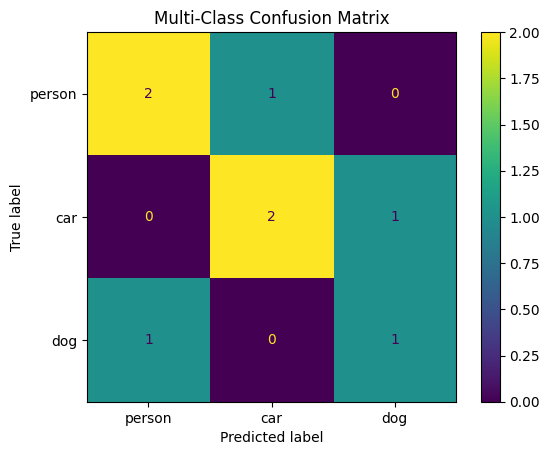

Confusion Matrix:
 [[2 1 0]
 [0 2 1]
 [1 0 1]]

Observation:
Diagonal values are correct predictions.
Off-diagonal values are classification errors.


In [19]:
#12. Interpreting Confusion Matrix Results for a Multi-Class Object Recognition Model
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

actual = ["person","person","car","car","dog","dog","person","car"]
pred   = ["person","car","car","car","dog","person","person","dog"]

classes = ["person","car","dog"]

cm = confusion_matrix(actual,pred,labels=classes)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
).plot()

plt.title("Multi-Class Confusion Matrix")
plt.show()

print("Confusion Matrix:\n",cm)
print("\nObservation:")
print("Diagonal values are correct predictions.")
print("Off-diagonal values are classification errors.")